### Prof. Pedram Jahangiry

You need to make a copy to your own Google drive if you want to edit the original notebook! Start by opening this notebook on Colab 👇

<a href="https://colab.research.google.com/github/PJalgotrader/Deep_Learning-USU/blob/main/Platforms%20and%20tools/PyCaret/PyCaret-RegressionDemo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> 



![logo](https://upload.wikimedia.org/wikipedia/commons/4/44/Huntsman-Wordmark-with-USU-Blue.gif#center) 


## 🔗 Links

[![linkedin](https://img.shields.io/badge/LinkedIn-0A66C2?style=for-the-badge&logo=linkedin&logoColor=white)](https://www.linkedin.com/in/pedram-jahangiry-cfa-5778015a)

[![Youtube](https://img.shields.io/badge/youtube_channel-1DA1F2?style=for-the-badge&logo=youtube&logoColor=white&color=FF0000)](https://www.youtube.com/channel/UCNDElcuuyX-2pSatVBDpJJQ)

[![Twitter URL](https://img.shields.io/twitter/url/https/twitter.com/PedramJahangiry.svg?style=social&label=Follow%20%40PedramJahangiry)](https://twitter.com/PedramJahangiry)


---


# ⚠️ Important: How to install PyCaret (read this first)

**We are using PyCaret 3.5.0, installed from the `pycaret-core` package.** The older `pycaret==3.3.2` release only supports Python 3.9 to 3.11 and is no longer updated, so `pip install pycaret` does not work on Google Colab or on any current Python. `pycaret-core` is the maintained continuation of PyCaret 3: same `import pycaret`, same functions, and it runs on Python 3.13.

### On Google Colab
Run the install cell below **first, in a fresh runtime**, before importing PyCaret. It detects Colab and runs:
```
pip install pycaret-core xgboost lightgbm catboost shap
```
This installs the PyCaret core library plus the three boosting libraries used in this notebook and `shap`, which `interpret_model()` needs.

No runtime restart is needed after the install. PyCaret checks which optional libraries exist the first time it is imported, so anything you install *after* importing it stays invisible (`Estimator ... Not Available`). If that happens, use Runtime ▸ Disconnect and delete runtime, then run the notebook from the top.

After the install finishes, verify with the version cell below (you should see **3.5.0**).

### On your own machine (conda)
The install cell does nothing outside Colab. Instead, create the course's PyCaret environment once, from the root of your cloned copy of this repo:
```
conda env create -f environment.yml
conda activate dl_pycaret
python scripts/check_environment.py
```
[`environment.yml`](https://github.com/PJalgotrader/Deep_Learning-USU/blob/main/environment.yml) uses **Python 3.13** (the same as Colab) and covers every PyCaret notebook in this course. The check script should end with "Your course environment is ready." Then open this notebook in JupyterLab or VS Code and pick the `dl_pycaret` environment as the kernel. Details and troubleshooting are in the [PyCaret setup guide](https://github.com/PJalgotrader/Deep_Learning-USU/blob/main/Platforms%20and%20tools/PyCaret/README.md). For a walkthrough of PyCaret itself, see my PyCaret playlist: https://www.youtube.com/playlist?list=PL2GWo47BFyUOqCAj_16yeNspfeM0nfA6q


Source:
1. https://py-caret.readthedocs.io/en/latest/tutorials.html (PyCaret tutorials)
2. https://py-caret.readthedocs.io/en/latest/api/regression.html (regression API reference)
3. https://pypi.org/project/pycaret-core/3.5.0/ (pycaret-core 3.5.0 on PyPI, the package we install in this notebook)
4. https://github.com/sktime/pycaret/releases (PyCaret release notes)


# How to do Regression with PyCaret

PyCaret's Regression module (pycaret.regression) is a supervised machine learning module which is used for predicting continuous values / outcomes using various techniques and algorithms. Regression can be used for predicting values / outcomes such as sales, units sold, temperature or any number which is continuous.

PyCaret's regression module has over 25 algorithms and 10 plots to analyze the performance of models. Be it hyper-parameter tuning, ensembling or advanced techniques like stacking, PyCaret's regression module has it all.

In this notebook, we will explore: 


* **Getting Data**: How to import data from PyCaret dataset
* **Normalization**: How to normalize and scale the dataset
* **Transformation**: How to apply transformations that make the data linear and approximately normal
* **Target Transformation**: How to apply transformations to the target variable
* **Ignore Low Variance**: How to remove features with statistically insignificant variances to make the experiment more efficient
* **Remove Multi-collinearity**: How to remove multi-collinearity from the dataset to boost performance of Linear algorithms
* **Group Features**: How to extract statistical information from related features in the dataset
* **Combine Rare Levels**: How to combine rare levels in categorical features
* **Bin Numeric Variables**: How to bin numeric variables and transform numeric features into categorical ones using 'sturges' rule
* **Setting up Environment**: How to setup an experiment in PyCaret and get started with building regression models
* **Create Model**: How to create a model, perform cross validation and evaluate regression metrics
* **Tune Model**: How to automatically tune the hyperparameters of a regression model
* **Plot Model**: How to analyze model performance using various plots
* **Finalize Model**: How to finalize the best model at the end of the experiment
* **Predict Model**: How to make prediction on new / unseen data
* **Model Ensembling and Stacking**: How to boost model performance using several ensembling techniques such as Bagging, Boosting, Soft/hard Voting and Generalized Stacking
* **Save / Load Model**: How to save / load a model for future use
* **Experiment Logging**: How to log experiments in PyCaret using MLFlow backend

# Installation

Follow the instructions at the top of this notebook: on Google Colab run the next cell; on your own machine use the `dl_pycaret` conda environment, where the next cell does nothing.

In [1]:
# Google Colab only: installs PyCaret 3.5.0 (pycaret-core) plus the libraries this notebook needs.
# On your own machine this cell does nothing (use the dl_pycaret conda environment, see the note above).
# shap is needed by interpret_model().
# Run it FIRST in a fresh runtime, before importing pycaret.
import sys
if "google.colab" in sys.modules:
    !pip install -q pycaret-core xgboost lightgbm catboost shap

In [2]:
# let's double ckeck the Pycaret version: 
from pycaret.utils import version
version()

'3.5.0'

# Importing Dataset

In [3]:
from pycaret.datasets import get_data

#here is the list of all available datasets
all_datasets = get_data('index')

,Dataset,Data Types,Default Task,Target Variable 1,Target Variable 2,# Instances,# Attributes,Missing Values
0,anomaly,Multivariate,Anomaly Detection,NaN,NaN,1000,10,N
1,france,Multivariate,Association Rule Mining,InvoiceNo,Description,8557,8,N
2,germany,Multivariate,Association Rule Mining,InvoiceNo,Description,9495,8,N
3,bank,Multivariate,Classification (Binary),deposit,NaN,45211,17,N
4,blood,Multivariate,Classification (Binary),Class,NaN,748,5,N
5,cancer,Multivariate,Classification (Binary),Class,NaN,683,10,N
6,credit,Multivariate,Classification (Binary),default,NaN,24000,24,N
7,diabetes,Multivariate,Classification (Binary),Class variable,NaN,768,9,N
8,electrical_grid,Multivariate,Classification (Binary),stabf,NaN,10000,14,N
9,employee,Multivariate,Classification (Binary),left,NaN,14999,10,N


In [4]:
dataset = get_data('bike')

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,1/1/2011,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,2,1/1/2011,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,3,1/1/2011,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,4,1/1/2011,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,5,1/1/2011,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


In [5]:
# dataset = get_data('bike', profile=True) # profile=True is going to do an automated EDA, you need to "pip install pycaret[analysis]" first. 

In [6]:
# for the sake of time, lets work with a tiny subsample of the data, 
dataset = dataset.sample(1000)

In [7]:
data = dataset.sample(frac=0.9, random_state=123)
data_unseen = dataset.drop(data.index)

data.reset_index(drop=True, inplace=True)
data_unseen.reset_index(drop=True, inplace=True)

print('Data for Modeling: ' + str(data.shape))
print('Unseen Data For Predictions: ' + str(data_unseen.shape))

Data for Modeling: (900, 15)
Unseen Data For Predictions: (100, 15)


In [8]:
data.shape

(900, 15)

In [9]:
data.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,11390,4/24/2012,2,1,4,18,0,2,1,1,0.50,0.4848,0.18,0.0000,632
1,14121,8/16/2012,3,1,8,13,0,4,1,1,0.80,0.6970,0.31,0.2239,300
2,5756,9/2/2011,3,0,9,6,0,5,1,1,0.60,0.5606,0.83,0.1343,76
3,5711,8/31/2011,3,0,8,9,0,3,1,1,0.64,0.6061,0.69,0.0896,244
4,14595,9/5/2012,3,1,9,7,0,3,1,2,0.70,0.6667,0.79,0.2537,500


In [10]:
data.nunique()

instant       900
dteday        528
season          4
yr              2
mnth           12
hr             24
holiday         2
weekday         7
workingday      2
weathersit      3
temp           46
atemp          55
hum            77
windspeed      24
cnt           423
dtype: int64

In [11]:
data.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt'],
      dtype='object')

In [12]:
categoricals = ['season', 'yr', 'mnth', 'hr','holiday', 'weekday','workingday','weathersit' ]
numericals   = ['temp', 'atemp', 'hum', 'windspeed']
ignore       = ['instant','dteday']

## Setting up Environment in PyCaret

**setup()**:

This function initializes the training environment and creates the transformation pipeline. Setup function must be called before executing any other function. It takes two mandatory parameters: data and target. All the other parameters are optional.

In [13]:
from pycaret.regression import *

The latest version of PyCaret is Object oriented API. This means that the settings are linked with an object, you can run as many experiments as you want in the same notebook and compare them seamlessly not just across different modeling options but also different preprocessing settings.


### ⚠️ A note on `data_split_shuffle=False`

On Python 3.13 with pandas ≥ 2.2 (both Google Colab and the `dl_pycaret` conda environment) PyCaret 3.5.0 has a preprocessing bug: when it merges transformed columns back into the dataset, pandas now **sorts the rows by index**, but the target column keeps its old order. Rows of `X` and `y` end up mismatched and any experiment with `preprocess=True` produces garbage scores (negative R²). Experiments with `preprocess=False` are not affected, but we use the same split settings in both so they stay comparable.

Our `data` is already shuffled (we built it with `.sample()` and reset the index), so PyCaret does not need to shuffle it again: `data_split_shuffle=False` keeps the row index in increasing order and the sort becomes a no-op. Do **not** set `fold_shuffle=True` on this stack for the same reason.


In [14]:
# experience1 = no preprocessing
exp1 = RegressionExperiment()
exp1.setup(data, ignore_features=ignore,  target='cnt', session_id=555, train_size=0.7, preprocess=False, categorical_features= categoricals, numeric_features=numericals,
           data_split_shuffle=False)   # see the note above (Colab / pandas >= 2.2)


,Description,Value
0,Session id,555
1,Target,cnt
2,Target type,Regression
3,Original data shape,"(900, 15)"
4,Transformed data shape,"(900, 13)"
5,Transformed train set shape,"(630, 13)"
6,Transformed test set shape,"(270, 13)"
7,Ignore features,2
8,Numeric features,4
9,Categorical features,8


In [15]:
# experiment 2, with preprocessing and more!!!
exp2 = RegressionExperiment()
exp2.setup(data, ignore_features=ignore, target='cnt', session_id=555, train_size=0.7, categorical_features= categoricals, numeric_features=numericals, numeric_imputation='mean', categorical_imputation='mode' ,
           preprocess=True, normalize=True , remove_outliers=True, ordinal_features=None,
           data_split_shuffle=False)   # see the note above (Colab / pandas >= 2.2)


,Description,Value
0,Session id,555
1,Target,cnt
2,Target type,Regression
3,Original data shape,"(900, 15)"
4,Transformed data shape,"(868, 58)"
5,Transformed train set shape,"(598, 58)"
6,Transformed test set shape,"(270, 58)"
7,Ignore features,2
8,Numeric features,4
9,Categorical features,8


## Compare Models

This function trains and evaluates performance of all estimators available in the model library using cross validation. The output of this function is a score grid with average cross validated scores. Metrics evaluated during CV can be accessed using the get_metrics function. Custom metrics can be added or removed using add_metric and remove_metric function.

In [16]:
top3_exp1 = exp1.compare_models(n_select=3)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
catboost,CatBoost Regressor,43.3430,3867.7493,61.6680,0.8880,0.6146,0.7850,0.1050
lightgbm,Light Gradient Boosting Machine,53.0142,5862.9816,75.6736,0.8312,0.6179,0.7523,0.0630
xgboost,Extreme Gradient Boosting,54.9553,6146.3298,77.5211,0.8221,0.6038,0.7281,0.0430
et,Extra Trees Regressor,57.3338,6602.0315,80.0643,0.8086,0.6370,0.9054,0.0140
gbr,Gradient Boosting Regressor,61.2336,7551.6825,86.2617,0.7817,0.7210,1.0754,0.0080
rf,Random Forest Regressor,62.8142,8682.7079,92.3343,0.7513,0.5632,0.6909,0.0150
knn,K Neighbors Regressor,70.8127,9948.1945,99.3670,0.7069,0.6953,1.0195,0.0040
ada,AdaBoost Regressor,95.3150,13319.4582,114.9440,0.6091,1.1029,2.7851,0.0080
dt,Decision Tree Regressor,83.3619,17280.4794,130.4311,0.4996,0.6865,0.7679,0.0020
ridge,Ridge Regression,108.4748,20482.0382,141.9920,0.4151,1.1822,3.2166,0.2010


In [17]:
top3_exp1

[CatBoostRegressor(border_count=254, loss_function='RMSE', random_state=555, task_type='CPU', verbose=False),
 LGBMRegressor(n_jobs=-1, random_state=555),
 XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cpu', early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=-1, num_parallel_tree=None, ...)]

In [18]:
top3_exp2 = exp2.compare_models(n_select=3)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
catboost,CatBoost Regressor,57.0139,6126.3565,77.7576,0.8221,0.7803,1.4127,0.1160
et,Extra Trees Regressor,66.1026,8602.9630,91.8801,0.7495,0.8075,1.4432,0.0340
gbr,Gradient Boosting Regressor,70.6181,9403.6641,96.2317,0.7260,0.8418,1.5282,0.0250
knn,K Neighbors Regressor,69.4679,9389.3407,96.4357,0.7227,0.7320,1.1393,0.0210
xgboost,Extreme Gradient Boosting,68.8837,9865.0877,97.9866,0.7180,0.8134,1.3999,0.0420
llar,Lasso Least Angle Regression,78.2556,10971.9019,104.1163,0.6787,0.9847,2.4177,0.0190
lasso,Lasso Regression,78.2567,10972.4543,104.1190,0.6787,0.9846,2.4179,0.0210
br,Bayesian Ridge,78.9491,10994.6040,104.2261,0.6785,0.9912,2.4305,0.0190
ridge,Ridge Regression,79.8330,11141.3043,104.9397,0.6730,0.9882,2.5549,0.0210
lr,Linear Regression,79.9297,11161.1372,105.0323,0.6724,0.9866,2.5620,0.0190


## Create Model

This function trains and evaluates the performance of a given estimator using cross validation. The output of this function is a score grid with CV scores by fold. Metrics evaluated during CV can be accessed using the get_metrics function. Custom metrics can be added or removed using add_metric and remove_metric function. All the available models can be accessed using the models function.

In [19]:
xgboost = exp1.create_model('xgboost')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,60.2139,6766.7129,82.2600,0.8027,0.6134,0.6000
1,49.4707,3796.8044,61.6182,0.8875,0.7120,0.9281
2,46.9345,4240.5688,65.1197,0.8927,0.5473,0.5040
3,64.8810,8308.1787,91.1492,0.8418,0.4728,0.5030
4,58.0069,6719.9502,81.9753,0.8116,0.6108,1.0076
5,45.6802,4838.3247,69.5581,0.8243,0.6518,0.6953
6,67.8975,10454.5977,102.2477,0.7542,0.6080,0.7638
7,49.0900,5928.1665,76.9946,0.8296,0.5125,0.5153
8,56.5052,5271.0254,72.6018,0.7390,0.7446,1.1929


## Tune model

This function tunes the hyperparameters of a given estimator. The output of this function is a score grid with CV scores by fold of the best selected model based on optimize parameter. Metrics evaluated during CV can be accessed using the get_metrics function. Custom metrics can be added or removed using add_metric and remove_metric function.

In [20]:
tune_xgboost = exp1.tune_model(xgboost)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,57.7093,6264.3423,79.1476,0.8173,0.5782,0.8457
1,46.1732,3947.6365,62.8302,0.8830,0.7174,0.9147
2,42.5686,3403.8313,58.3424,0.9139,0.5847,0.7981
3,57.3572,5977.6538,77.3153,0.8861,0.5010,0.5118
4,48.9163,4445.7256,66.6763,0.8754,0.6362,1.0488
5,41.5291,3537.5037,59.4769,0.8715,0.7718,0.9954
6,60.5404,7547.4849,86.8763,0.8226,0.6127,0.7278
7,53.5661,6503.1050,80.6418,0.8131,0.6198,0.8012
8,43.7117,3548.4915,59.5692,0.8243,0.6340,0.9494


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [21]:
xgboost

,objective,'reg:squarederror'
,base_score,None
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,'cpu'
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [22]:
tune_xgboost

,objective,'reg:squarederror'
,base_score,None
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,'cpu'
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


## Plot Model

This function analyzes the performance of a trained model on holdout set. It may require re-training the model in certain cases

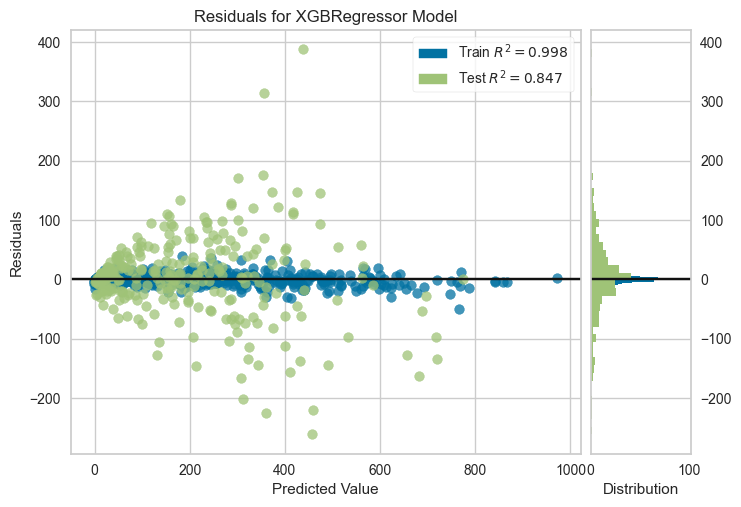

In [23]:
exp1.plot_model(tune_xgboost)

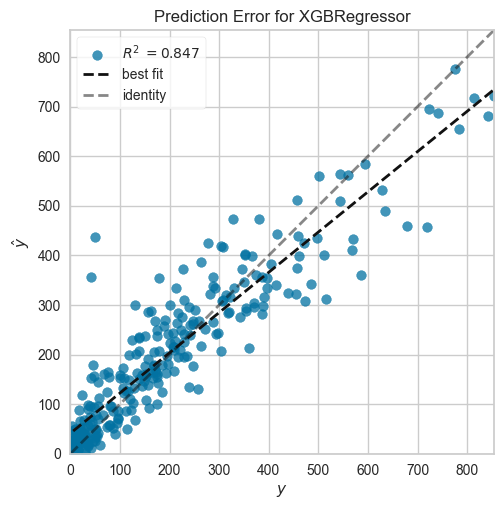

In [24]:
exp1.plot_model(tune_xgboost, plot = 'error')

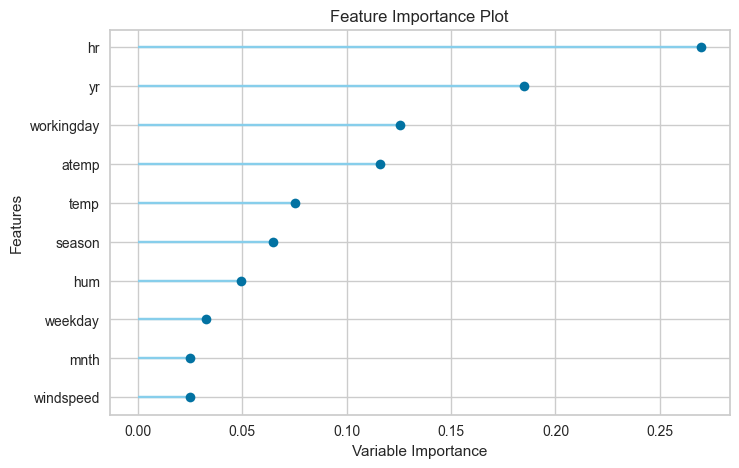

In [25]:
exp1.plot_model(tune_xgboost, plot = 'feature')

In [26]:
exp1.plot_model(tune_xgboost, plot = 'parameter')

,Parameters
objective,reg:squarederror
base_score,None
booster,gbtree
callbacks,None
colsample_bylevel,None
colsample_bynode,None
colsample_bytree,0.7
device,cpu
early_stopping_rounds,None
enable_categorical,True


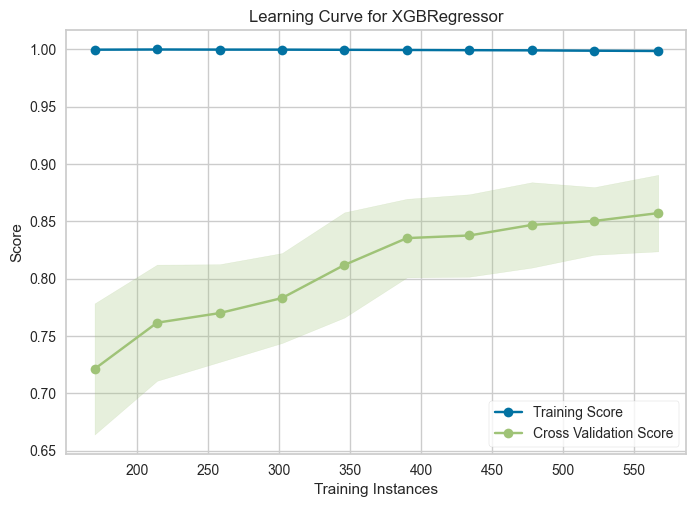

In [27]:
exp1.plot_model(tune_xgboost, plot = 'learning')

the model has high variance, increasing sample size will help. 

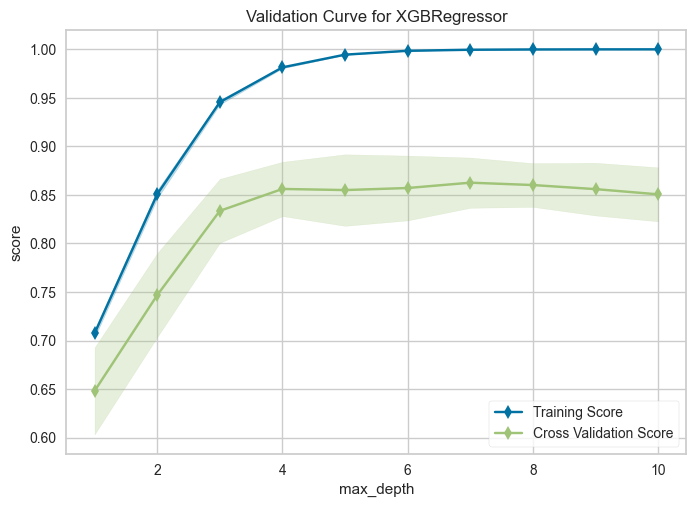

In [28]:
exp1.plot_model(tune_xgboost, plot = 'vc')

As you can see, the model is overfitting with max_depth = 9. 

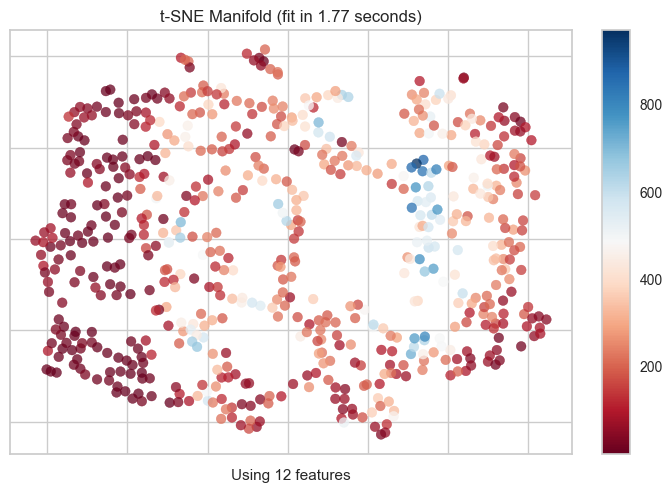

In [29]:
exp1.plot_model(tune_xgboost, plot = 'manifold')

## Evaluate model

This function displays a user interface for analyzing performance of a trained model. It calls the plot_model function internally.

*I don't recommend using this evaluate model functionality! very slow plus bugs! do separate plots instead.*

In [30]:
lr = exp1.create_model('lr', fold=5)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,106.6966,18395.6934,135.6307,0.4698,1.2599,3.8291
1,131.9147,28481.7598,168.7654,0.3815,1.1847,2.4230
2,106.0007,20532.6465,143.2922,0.3537,1.2687,3.8517
3,99.7465,20059.5215,141.6316,0.4840,1.0300,2.1948
4,95.7868,14807.2842,121.6852,0.4304,1.2292,4.0011
Mean,108.0291,20455.3811,142.2010,0.4239,1.1945,3.2599
Std,12.6086,4488.4015,15.3052,0.0500,0.0873,0.7821


In [31]:
exp1.evaluate_model(lr)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

## Interpret model

This function analyzes the predictions generated from a trained model. Most plots in this function are implemented based on the SHAP (SHapley Additive exPlanations). For more info on this, please see https://shap.readthedocs.io/en/latest/

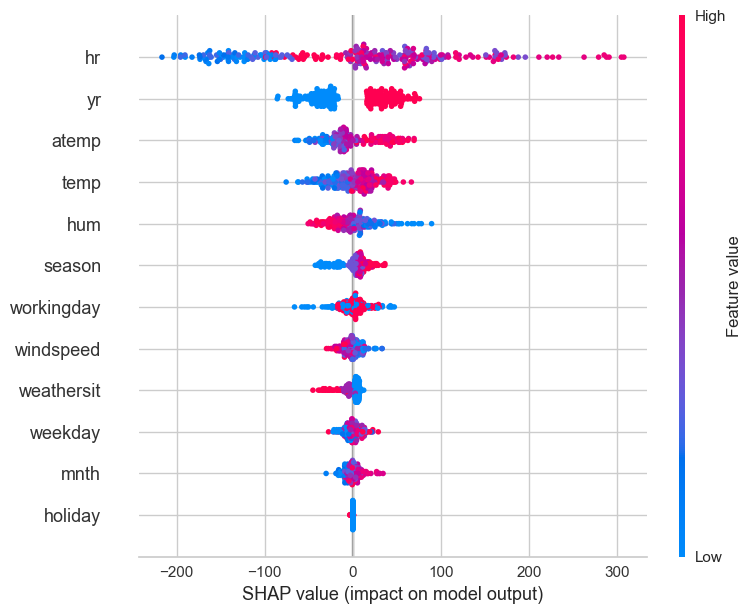

In [32]:
exp1.interpret_model(tune_xgboost)

## Ensemble a Model
Ensembling is a common machine learning technique used to improve the performance of models (mostly tree based). There are various techniques for ensembling that we will cover in this section. These include Bagging and Boosting

In [33]:
# lets create a simple decision tree model that we will use for ensembling 
dt = exp1.create_model('dt')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,95.6825,18570.5397,136.2738,0.4585,0.6993,0.7363
1,82.5079,19155.0476,138.4018,0.4322,0.7150,0.7655
2,68.5079,16305.3016,127.6922,0.5874,0.6945,0.6483
3,98.0317,22194.4127,148.9779,0.5773,0.6132,0.5968
4,90.6825,17007.0000,130.4109,0.5233,0.7791,0.9958
5,58.3333,9506.1746,97.4996,0.6548,0.6266,0.6475
6,101.3651,24866.8571,157.6923,0.4155,0.6654,0.8387
7,79.1429,17477.2381,132.2015,0.4976,0.5955,0.5681
8,79.2698,15270.1905,123.5726,0.2440,0.7539,1.0357


In [34]:
bagged_dt = exp1.ensemble_model(dt)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,68.6032,10369.8219,101.8323,0.6976,0.5340,0.6077
1,62.9968,7938.8765,89.1004,0.7647,0.6014,0.7254
2,63.5254,8880.5890,94.2369,0.7753,0.4391,0.4229
3,81.7540,14391.2916,119.9637,0.7259,0.4946,0.5013
4,73.3810,10370.6025,101.8362,0.7093,0.7168,0.9962
5,55.8270,8322.6494,91.2286,0.6978,0.6125,0.7365
6,80.8333,15311.9532,123.7415,0.6401,0.6022,0.6952
7,57.2302,9926.8551,99.6336,0.7146,0.5200,0.5573
8,59.4111,6376.1983,79.8511,0.6843,0.6307,0.8386


In [35]:
boosted_dt = exp1.ensemble_model(dt, method = 'Boosting')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,68.0794,8492.0159,92.1521,0.7524,0.5366,0.6374
1,60.5873,8611.0952,92.7960,0.7448,0.5371,0.5817
2,43.2222,4968.3651,70.4866,0.8743,0.5476,0.5745
3,75.0794,14607.2063,120.8603,0.7218,0.5577,0.5595
4,71.8254,11310.9683,106.3530,0.6830,0.6584,0.8325
5,60.9365,9716.7460,98.5736,0.6471,0.6855,0.8059
6,82.9048,17890.0476,133.7537,0.5795,0.6160,0.6395
7,55.9683,7963.0794,89.2361,0.7711,0.4628,0.4580
8,55.9683,6698.8571,81.8465,0.6684,0.6435,0.7684


## Blending and Stacking

* **Blend** trains a Voting Regressor for select models passed in the estimator_list param. It creates multiple models and then averages the individual predictions to form a final prediction. 


* **Stack** trains a meta model over select estimators passed in the estimator_list parameter. Stacking is another popular technique for ensembling but is less commonly implemented due to practical difficulties. Stacking is an ensemble learning technique that combines multiple models via a meta-model. Another way to think about stacking is that multiple models are trained to predict the outcome and a meta-model is created that uses the predictions from those models as an input along with the original features. The implementation of stack_models() is based on Wolpert, D. H. (1992b). Stacked generalization


In [36]:
top3_exp1

[CatBoostRegressor(border_count=254, loss_function='RMSE', random_state=555, task_type='CPU', verbose=False),
 LGBMRegressor(n_jobs=-1, random_state=555),
 XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cpu', early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=-1, num_parallel_tree=None, ...)]

In [37]:
blender = exp1.blend_models(estimator_list = top3_exp1)
# you can use any mix of models:) for example ['rf','xgboost', 'lr']

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,53.1158,5238.6245,72.3783,0.8473,0.6338,0.7484
1,41.1669,3090.1347,55.5890,0.9084,0.6428,0.7412
2,42.0857,3446.2200,58.7045,0.9128,0.5687,0.6097
3,56.5777,6070.4164,77.9129,0.8844,0.4183,0.4376
4,49.5876,5228.9226,72.3113,0.8534,0.5673,0.8124
5,40.5629,3788.3785,61.5498,0.8624,0.5808,0.6898
6,60.4871,7894.9291,88.8534,0.8144,0.6121,0.7573
7,48.1249,5632.0556,75.0470,0.8381,0.5185,0.5062
8,44.9761,3725.7493,61.0389,0.8155,0.6666,0.9286


In [38]:
blender

,estimators,"[('CatBoost Regressor', ...), ('Light Gradient Boosting Machine', ...), ...]"
,weights,None
,n_jobs,-1
,verbose,False
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None


Now that we have created a VotingRegressor using the blend_models() function. The model returned by the blend_models function is just like any other model that you would create using create_model() or tune_model(). You can use this model for predictions on unseen data using predict_model() in the same way you would for any other model.

In [39]:
stacker = exp1.stack_models(estimator_list=top3_exp1)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,47.4907,4168.4139,64.5633,0.8785,0.6428,1.0864
1,38.7102,2493.2281,49.9322,0.9261,0.8098,1.0388
2,40.1655,3372.9588,58.0772,0.9146,0.5496,0.7442
3,50.3394,4639.0467,68.1105,0.9116,0.6221,0.5117
4,47.7989,4517.1005,67.2094,0.8734,0.5934,0.7320
5,42.0517,2927.2044,54.1036,0.8937,0.6631,0.8368
6,51.1846,5342.5200,73.0925,0.8744,0.6980,0.8283
7,46.6352,5090.8089,71.3499,0.8537,0.7016,0.7098
8,41.1069,3352.8530,57.9038,0.8340,0.6896,0.9720


 !!! It's always good to look at the standard deviation of CV results

In [40]:
stacker

,estimators,"[('CatBoost Regressor', ...), ('Light Gradient Boosting Machine', ...), ...]"
,final_estimator,LinearRegression(n_jobs=-1)
,cv,5
,n_jobs,-1
,passthrough,False
,verbose,0
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100


By default, the meta model (final model to generate predictions) is Linear Regression. The meta model can be changed using the meta_model parameter. See an example below:

In [41]:
xgboost = exp1.create_model('xgboost')
stacker_xgboost = exp1.stack_models(top3_exp1, meta_model = xgboost)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,60.2139,6766.7129,82.2600,0.8027,0.6134,0.6000
1,49.4707,3796.8044,61.6182,0.8875,0.7120,0.9281
2,46.9345,4240.5688,65.1197,0.8927,0.5473,0.5040
3,64.8810,8308.1787,91.1492,0.8418,0.4728,0.5030
4,58.0069,6719.9502,81.9753,0.8116,0.6108,1.0076
5,45.6802,4838.3247,69.5581,0.8243,0.6518,0.6953
6,67.8975,10454.5977,102.2477,0.7542,0.6080,0.7638
7,49.0900,5928.1665,76.9946,0.8296,0.5125,0.5153
8,56.5052,5271.0254,72.6018,0.7390,0.7446,1.1929


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,66.4078,8190.4077,90.5009,0.7612,0.5095,0.5383
1,41.3071,3532.1804,59.4321,0.8953,0.7452,0.9217
2,64.5377,8956.7197,94.6399,0.7734,0.5894,0.7362
3,51.3384,5884.1401,76.7082,0.8879,0.5451,0.4261
4,53.7895,5238.0220,72.3742,0.8532,0.5992,0.7847
5,42.7830,3533.0015,59.4391,0.8717,0.6785,0.8613
6,51.9906,5093.1099,71.3660,0.8803,0.6146,0.6406
7,58.5118,8242.3066,90.7871,0.7631,0.5541,0.6124
8,51.8067,5849.3647,76.4811,0.7104,0.6593,0.9292


In [42]:
stacker_xgboost

,estimators,"[('CatBoost Regressor', ...), ('Light Gradient Boosting Machine', ...), ...]"
,final_estimator,"XGBRegressor(...ree=None, ...)"
,cv,5
,n_jobs,-1
,passthrough,False
,verbose,0
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100


Before we wrap up this section, there is another parameter in stack_models() that we haven't seen yet called restack. This parameter controls the ability to expose the raw data to the meta model. When set to True, it exposes the raw data to the meta model along with all the predictions of the base level models. By default it is set to True

## AutoML

This function returns the best model out of all trained models in current session based on the optimize parameter. Metrics evaluated can be accessed using the get_metrics function.

*I don't recommend doing it this way! very slow!*

In [43]:
# CatBoost >= 1.2.6 rejects NumPy integers in scikit-learn's clone(), which breaks PyCaret's default
# CatBoost tuning grid on Google Colab. If CatBoost is among the models, tune it with a custom grid
# of plain Python numbers instead (the other models keep PyCaret's default grid).
catboost_grid = {
    'depth':        [4, 6, 8, 10],
    'eta':          [0.01, 0.05, 0.1, 0.3],   # learning rate
    'n_estimators': [100, 200, 300, 500],
    'l2_leaf_reg':  [1, 3, 5, 10],
}


In [44]:
# we already have top3_expr1, blender and stacker so far. Let's make tuned_top3_expr1 and pick the best one.

tuned_top3_expr = [
    exp1.tune_model(i, custom_grid=catboost_grid if 'CatBoost' in type(i).__name__ else None)
    for i in top3_exp1
]
best_R2_model = exp1.automl(optimize = 'R2')


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,50.4321,5237.0138,72.3672,0.8473,0.6630,1.4293
1,42.2053,3001.2267,54.7835,0.9110,0.8384,1.1005
2,40.4198,3304.6249,57.4859,0.9164,0.7413,1.1367
3,45.8896,4068.7250,63.7866,0.9225,0.4425,0.4235
4,48.0790,4511.0748,67.1645,0.8736,0.6801,1.2558
5,38.2909,2953.6172,54.3472,0.8927,0.6728,0.8773
6,52.1750,6041.8980,77.7296,0.8580,0.6975,1.0146
7,43.5215,4664.4402,68.2967,0.8659,0.6934,0.7880
8,40.0990,3085.6843,55.5489,0.8472,0.7369,1.2971


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,64.8999,9053.8133,95.1515,0.7360,0.5996,0.7645
1,50.2466,4382.5597,66.2009,0.8701,0.7531,0.9413
2,62.1049,7429.8571,86.1966,0.8120,0.8010,1.3925
3,72.5285,8535.5372,92.3880,0.8374,0.7110,0.9283
4,68.0816,8140.1655,90.2229,0.7718,0.7606,1.9563
5,58.6140,6837.9134,82.6917,0.7517,0.8245,1.3846
6,70.0213,10342.2379,101.6968,0.7569,0.6611,0.8049
7,58.4534,6185.1057,78.6454,0.8222,0.9925,1.7542
8,61.0609,6222.3347,78.8818,0.6919,0.8743,1.8909


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,57.7093,6264.3423,79.1476,0.8173,0.5782,0.8457
1,46.1732,3947.6365,62.8302,0.8830,0.7174,0.9147
2,42.5686,3403.8313,58.3424,0.9139,0.5847,0.7981
3,57.3572,5977.6538,77.3153,0.8861,0.5010,0.5118
4,48.9163,4445.7256,66.6763,0.8754,0.6362,1.0488
5,41.5291,3537.5037,59.4769,0.8715,0.7718,0.9954
6,60.5404,7547.4849,86.8763,0.8226,0.6127,0.7278
7,53.5661,6503.1050,80.6418,0.8131,0.6198,0.8012
8,43.7117,3548.4915,59.5692,0.8243,0.6340,0.9494


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [45]:
best_R2_model

CatBoostRegressor(border_count=254, loss_function='RMSE', random_state=555, task_type='CPU', verbose=False)

## Predict Model

This function predicts Label using a trained model. When data is None, it predicts label on the holdout set.

note: so far, our best model is the stacker model with the highest CV R2. :)


In [46]:
holdout_pred = exp1.predict_model(stacker)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Stacking Regressor,40.6716,3189.9772,56.4799,0.9065,0.5487,0.6132


## Finalize Model

This function trains a given estimator on the entire dataset including the holdout set.

Model finalization is the last step in the experiment. A normal machine learning workflow in PyCaret starts with setup(), followed by comparing all models using compare_models() and shortlisting a few candidate models (based on the metric of interest) to perform several modeling techniques such as hyperparameter tuning, ensembling, stacking etc. This workflow will eventually lead you to the best model for use in making predictions on new and unseen data. The finalize_model() function fits the model onto the complete dataset including the test/hold-out sample (30% in this case). The purpose of this function is to train the model on the complete dataset before it is deployed in production.

In [47]:
final_stacker = exp1.finalize_model(stacker)

In [48]:
final_stacker

,steps,"[('placeholder', ...), ('actual_estimator', ...)]"
,memory,Memory(location=None)
,verbose,False
,estimators,"[('CatBoost Regressor', ...), ('Light Gradient Boosting Machine', ...), ...]"
,final_estimator,LinearRegression(n_jobs=-1)
,cv,5
,n_jobs,-1
,passthrough,False
,verbose,0
,boosting_type,'gbdt'
,num_leaves,31


### Final prediciton on unseen data

The predict_model() function is also used to predict on the unseen dataset. The only difference from section 11 above is that this time we will pass the data_unseen parameter. data_unseen is the variable created at the beginning of the tutorial and contains 10% of the original dataset which was never exposed to PyCaret.

In [49]:
unseen_predictions = exp1.predict_model(final_stacker, data=data_unseen)
unseen_predictions.tail()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Stacking Regressor,32.8933,2015.1268,44.8902,0.9281,0.5088,0.7269


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,prediction_label
95,14959,9/20/2012,3,1,9,11,0,4,1,1,0.62,0.6212,0.43,0.0000,243,337.336779
96,9419,2/2/2012,1,1,2,8,0,4,1,3,0.40,0.4091,0.87,0.0000,445,332.770565
97,15874,10/28/2012,4,1,10,14,0,0,0,2,0.50,0.4848,0.59,0.4478,402,428.502890
98,15938,11/1/2012,4,1,11,18,0,4,1,2,0.40,0.4091,0.50,0.1642,678,569.470162
99,17174,12/23/2012,1,1,12,8,0,0,0,1,0.14,0.1667,0.69,0.1045,48,48.458711


## Save Model

This function saves the transformation pipeline and trained model object into the current working directory as a pickle file for later use.

In [50]:
exp1.save_model(final_stacker, 'my_pycaret_regression')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('placeholder', None),
                 ('actual_estimator',
                  StackingRegressor(cv=5,
                                    estimators=[('CatBoost Regressor',
                                                 CatBoostRegressor(border_count=254, loss_function='RMSE', random_state=555, task_type='CPU', verbose=False)),
                                                ('Light Gradient Boosting '
                                                 'Machine',
                                                 LGBMRegressor(n_jobs=-1,
                                                               random_state=555)),
                                                ('Extreme Gradient Boosting'...
                                                              interaction_constraints=None,
                                                              learning_rate=None,
                                                              m

## Load model

This function loads a previously saved pipeline.



In [51]:
my_winning_regressor = load_model('my_pycaret_regression')

Transformation Pipeline and Model Successfully Loaded


In [52]:
my_winning_regressor

,steps,"[('placeholder', ...), ('actual_estimator', ...)]"
,memory,Memory(location=None)
,verbose,False
,estimators,"[('CatBoost Regressor', ...), ('Light Gradient Boosting Machine', ...), ...]"
,final_estimator,LinearRegression(n_jobs=-1)
,cv,5
,n_jobs,-1
,passthrough,False
,verbose,0
,boosting_type,'gbdt'
,num_leaves,31


## Deploy Model

This function deploys the transformation pipeline and trained model on cloud.

https://py-caret.readthedocs.io/en/latest/api/generated/pycaret.regression.deploy_model.html